📊 Student Feedback Analysis Project

This notebook analyzes student event feedback collected through surveys.  
The workflow includes:

✅ Cleaning and preparing feedback data (from Google Form export)  
✅ Analyzing ratings (1–5 scale) to find patterns of satisfaction  
✅ Performing sentiment analysis (positive/neutral/negative) on comments  
✅ Visualizing trends with clear charts and graphs  
✅ Suggesting improvements for future events based on findings  

---

🔎 **Objective:**  
To uncover satisfaction trends and provide actionable recommendations that can help improve future student events.

In [1]:
# Setup & imports
!pip install -q nltk textblob

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from textblob import TextBlob
import nltk

# Try to download NLTK resources (Colab usually has internet)
try:
    nltk.download('vader_lexicon')
    nltk.download('punkt')
except Exception as e:
    print("NLTK download failed (this can happen offline). Vader will be attempted, with fallback to TextBlob. Error:", e)

from nltk.sentiment.vader import SentimentIntensityAnalyzer

print("Imports ready. Move to data-loading cell.")


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Imports ready. Move to data-loading cell.


In [4]:
# Load data & preview
# Change the path if your CSV is stored elsewhere (e.g., Google Drive).
PATH = "/content/student_feedback.csv"

df = pd.read_csv(PATH)
print("Rows, Columns:", df.shape)
display(df.head(10))
print("\nColumn types:")
print(df.dtypes)


Rows, Columns: (1001, 10)


,Unnamed: 0,Student ID,Well versed with the subject,Explains concepts in an understandable way,Use of presentations,Degree of difficulty of assignments,Solves doubts willingly,Structuring of the course,Provides support for students going above and beyond,Course recommendation based on relevance
0,0,340,5,2,7,6,9,2,1,8
1,1,253,6,5,8,6,2,1,2,9
2,2,680,7,7,6,5,4,2,3,1
3,3,806,9,6,7,1,5,9,4,6
4,4,632,8,10,8,4,6,6,9,9
5,5,832,7,2,7,8,3,5,1,4
6,6,772,9,3,5,2,10,3,8,1
7,7,961,9,8,7,4,4,3,3,10
8,8,814,6,5,8,6,4,4,7,9
9,9,863,5,9,4,7,9,4,4,5



Column types:
Unnamed: 0                                              int64
Student ID                                              int64
Well versed with the subject                            int64
Explains concepts in an understandable way              int64
Use of presentations                                    int64
Degree of difficulty of assignments                     int64
Solves doubts willingly                                 int64
Structuring of the course                               int64
Provides support for students going above and beyond    int64
Course recommendation based on relevance                int64
dtype: object


In [5]:
# Identify rating columns and text/comment columns
# This inspects columns and decides which are likely ratings (numeric) and which are comments (text).
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
text_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()

# Heuristic: numeric columns with many unique values likely not IDs -> candidate rating columns
rating_candidates = []
id_like = []
for col in numeric_cols:
    nunique = df[col].nunique()
    if nunique <= 20 and nunique > 2:
        rating_candidates.append(col)
    else:
        # Could be Student ID or index
        id_like.append(col)

print("Numeric columns:", numeric_cols)
print("Detected rating candidates (heuristic):", rating_candidates)
print("Possible ID-like numeric columns:", id_like)
print("Text columns (possible comments):", text_cols)

# If the dataframe has an 'Unnamed: 0' auto index column, drop it
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
    print("Dropped column 'Unnamed: 0'")

Numeric columns: ['Unnamed: 0', 'Student ID', 'Well versed with the subject', 'Explains concepts in an understandable way', 'Use of presentations', 'Degree of difficulty of assignments', 'Solves doubts willingly', 'Structuring of the course', 'Provides support for students going above and beyond', 'Course recommendation based on relevance']
Detected rating candidates (heuristic): ['Well versed with the subject', 'Explains concepts in an understandable way', 'Use of presentations', 'Degree of difficulty of assignments', 'Solves doubts willingly', 'Structuring of the course', 'Provides support for students going above and beyond', 'Course recommendation based on relevance']
Possible ID-like numeric columns: ['Unnamed: 0', 'Student ID']
Text columns (possible comments): []
Dropped column 'Unnamed: 0'


In [6]:
# Normalize ratings to 1-5 scale
def detect_scale_and_normalize(series):
    # If values exceed 5, rescale linearly to 1-5
    s = series.dropna().astype(float)
    if s.empty:
        return series
    minv, maxv = s.min(), s.max()
    # if already within 1..5, return rounded to nearest 0.1
    if minv >= 1 and maxv <= 5:
        return series.astype(float).round(1)
    # If scale looks 0-10 or 1-10 rescale
    # Map [minv, maxv] -> [1,5]
    def rescale(x):
        try:
            return 1 + (float(x) - minv) * (4.0 / (maxv - minv))
        except:
            return np.nan
    return series.apply(lambda x: rescale(x)).round(2)

rating_cols = rating_candidates.copy()
print("Rating columns to normalize:", rating_cols)

for c in rating_cols:
    df[c + "_norm"] = detect_scale_and_normalize(df[c])

print("Added normalized columns with suffix '_norm'. Preview:")
display(df[[c for c in df.columns if c.endswith('_norm')]].head())


Rating columns to normalize: ['Well versed with the subject', 'Explains concepts in an understandable way', 'Use of presentations', 'Degree of difficulty of assignments', 'Solves doubts willingly', 'Structuring of the course', 'Provides support for students going above and beyond', 'Course recommendation based on relevance']
Added normalized columns with suffix '_norm'. Preview:


,Well versed with the subject_norm,Explains concepts in an understandable way_norm,Use of presentations_norm,Degree of difficulty of assignments_norm,Solves doubts willingly_norm,Structuring of the course_norm,Provides support for students going above and beyond_norm,Course recommendation based on relevance_norm
0,1.0,1.0,4.0,3.22,4.56,1.44,1.00,4.11
1,1.8,2.5,5.0,3.22,1.44,1.00,1.44,4.56
2,2.6,3.5,3.0,2.78,2.33,1.44,1.89,1.00
3,4.2,3.0,4.0,1.00,2.78,4.56,2.33,3.22
4,3.4,5.0,5.0,2.33,3.22,3.22,4.56,4.56


In [7]:
#Summary statistics & satisfaction trends
norm_cols = [c for c in df.columns if c.endswith('_norm')]
summary = df[norm_cols].describe().T[['count','mean','std','min','25%','50%','75%','max']]
summary = summary.rename(columns={'mean':'avg_rating'})
display(summary)

# Identify highest and lowest scoring items
top = summary.sort_values('avg_rating', ascending=False).head(5)
bottom = summary.sort_values('avg_rating', ascending=True).head(5)
print("Top 5 highest average satisfaction items:\n", top)
print("\nTop 5 lowest average satisfaction items:\n", bottom)


,count,avg_rating,std,min,25%,50%,75%,max
Well versed with the subject_norm,1001.0,2.998002,1.354399,1.0,1.80,3.40,4.20,5.0
Explains concepts in an understandable way_norm,1001.0,3.040959,1.298584,1.0,2.00,3.00,4.00,5.0
Use of presentations_norm,1001.0,2.942058,1.415853,1.0,2.00,3.00,4.00,5.0
Degree of difficulty of assignments_norm,1001.0,2.969081,1.276328,1.0,1.89,2.78,4.11,5.0
Solves doubts willingly_norm,1001.0,2.988601,1.278818,1.0,1.89,3.22,4.11,5.0
Structuring of the course_norm,1001.0,3.060539,1.298979,1.0,1.89,3.22,4.11,5.0
Provides support for students going above and beyond_norm,1001.0,3.072258,1.286338,1.0,1.89,3.22,4.11,5.0
Course recommendation based on relevance_norm,1001.0,3.043776,1.284152,1.0,1.89,3.22,4.11,5.0


Top 5 highest average satisfaction items:
                                                      count  avg_rating  \
Provides support for students going above and b...  1001.0    3.072258   
Structuring of the course_norm                      1001.0    3.060539   
Course recommendation based on relevance_norm       1001.0    3.043776   
Explains concepts in an understandable way_norm     1001.0    3.040959   
Well versed with the subject_norm                   1001.0    2.998002   

                                                         std  min   25%   50%  \
Provides support for students going above and b...  1.286338  1.0  1.89  3.22   
Structuring of the course_norm                      1.298979  1.0  1.89  3.22   
Course recommendation based on relevance_norm       1.284152  1.0  1.89  3.22   
Explains concepts in an understandable way_norm     1.298584  1.0  2.00  3.00   
Well versed with the subject_norm                   1.354399  1.0  1.80  3.40   

                         

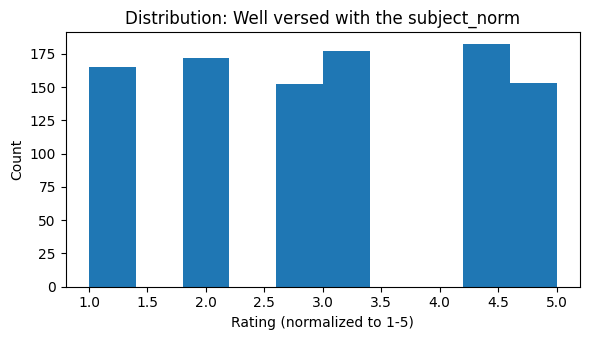

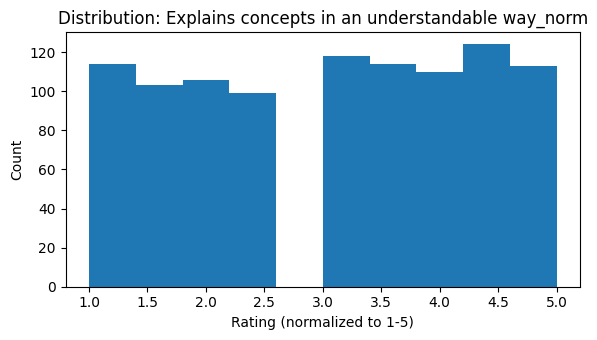

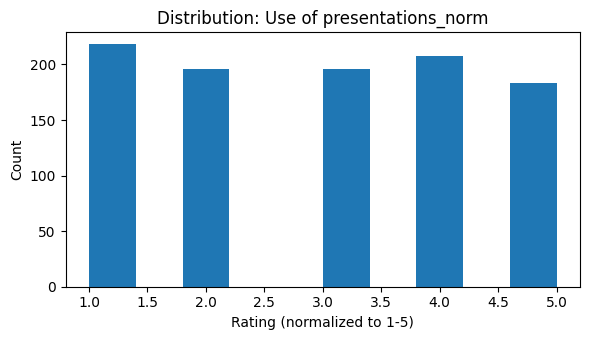

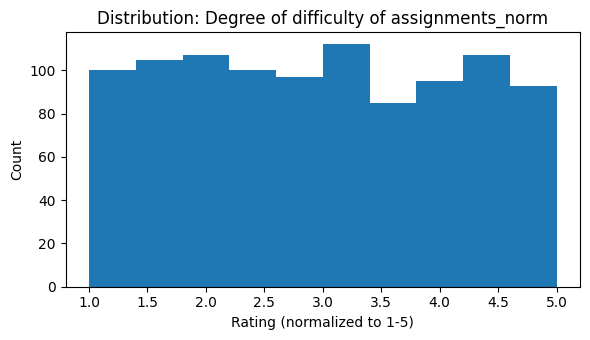

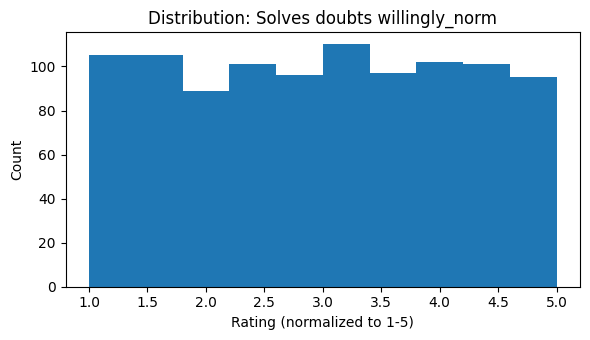

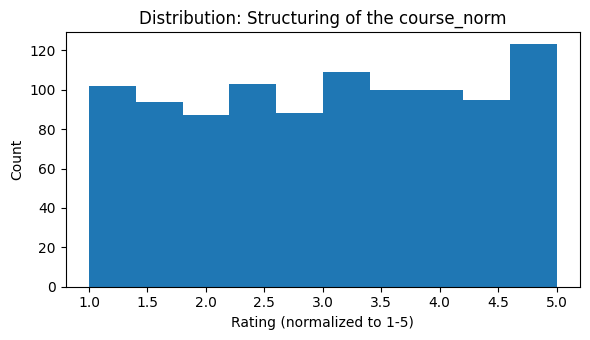

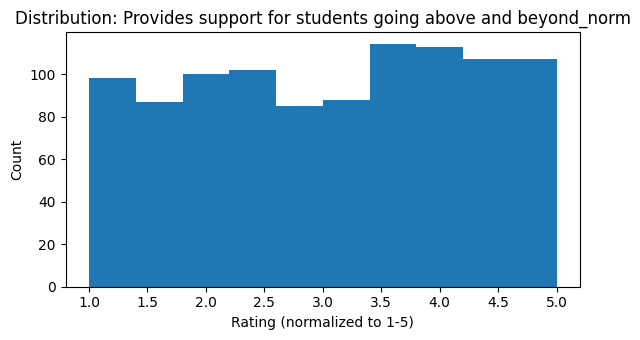

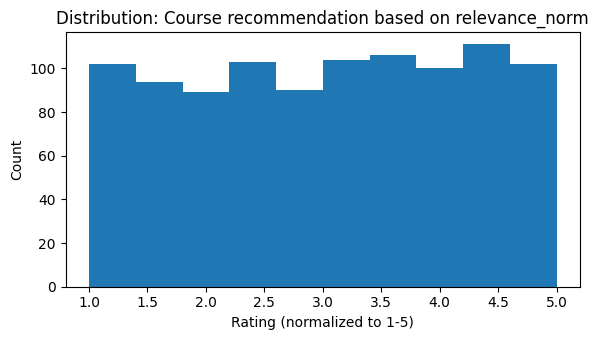

In [8]:
# Plots: distribution histograms (one chart per cell recommended)
# This cell will create one figure per rating metric; if many metrics exist consider plotting a subset.

for col in norm_cols:
    plt.figure(figsize=(6,3.5))
    plt.title(f"Distribution: {col}")
    # dropna so plotting works
    vals = df[col].dropna().astype(float)
    plt.hist(vals, bins=10)    # matplotlib histogram
    plt.xlabel("Rating (normalized to 1-5)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


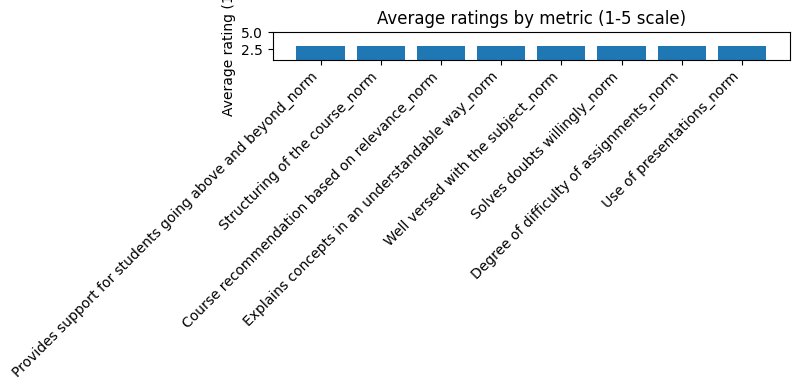

In [9]:
# Bar chart of average ratings (one plot)
avg_ratings = df[norm_cols].mean().sort_values(ascending=False)
plt.figure(figsize=(8,4))
plt.title("Average ratings by metric (1-5 scale)")
plt.bar(avg_ratings.index, avg_ratings.values)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Average rating (1-5)")
plt.ylim(1,5)
plt.tight_layout()
plt.show()


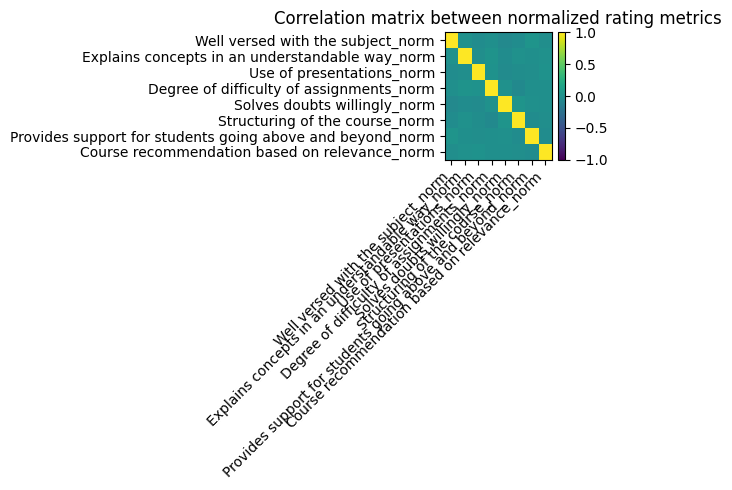

Top positive correlations:
                                             metric1  \
37                     Solves doubts willingly_norm   
6                 Well versed with the subject_norm   
11  Explains concepts in an understandable way_norm   
23                        Use of presentations_norm   
19                        Use of presentations_norm   

                                              metric2      corr  
37                     Structuring of the course_norm  0.036044  
6   Provides support for students going above and ...  0.031526  
11           Degree of difficulty of assignments_norm  0.029566  
23      Course recommendation based on relevance_norm  0.023138  
19           Degree of difficulty of assignments_norm  0.020871  

Top negative correlations:
                                               metric1  \
4                   Well versed with the subject_norm   
29           Degree of difficulty of assignments_norm   
20                          Use of presentati

In [10]:
# Correlation between metrics (visualized with imshow)
corr = df[norm_cols].corr()
plt.figure(figsize=(6,5))
plt.title("Correlation matrix between normalized rating metrics")
plt.imshow(corr, aspect='auto', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.index)), corr.index)
plt.tight_layout()
plt.show()

# Print strongest positive & negative correlations (pairs)
corr_values = corr.unstack().reset_index()
corr_values.columns = ['metric1','metric2','corr']
# Remove self correlations and duplicates
corr_values = corr_values[corr_values['metric1'] != corr_values['metric2']]
corr_values['pair'] = corr_values.apply(lambda r: tuple(sorted([r['metric1'], r['metric2']])), axis=1)
corr_values = corr_values.drop_duplicates(subset='pair')
top_pos = corr_values.sort_values('corr', ascending=False).head(5)
top_neg = corr_values.sort_values('corr', ascending=True).head(5)
print("Top positive correlations:\n", top_pos[['metric1','metric2','corr']])
print("\nTop negative correlations:\n", top_neg[['metric1','metric2','corr']])


Here are the improvement suggestions from the student feedback analysis:

Improve Use of presentations — current avg rating 2.94. Consider clearer instructions, more engaging activities, or follow-up support.

Improve Degree of difficulty of assignments — current avg rating 2.97. Consider clearer instructions, more engaging activities, or follow-up support.

Improve Solves doubts willingly — current avg rating 2.99. Consider clearer instructions, more engaging activities, or follow-up support.

Improve Well versed with the subject — current avg rating 3.00. Consider clearer instructions, more engaging activities, or follow-up support.

Improve Explains concepts in an understandable way — current avg rating 3.04. Consider clearer instructions, more engaging activities, or follow-up support.